# 05 - Results Visualization

This notebook parses the benchmark outcomes from `results/tables/experiment_results.csv` and visualizes the robustness curves for each defense under both FGSM and PGD attacks.

Loaded 41 evaluation rows from ../results/tables/experiment_results.csv.
Robustness curve visualization saved to ../results/figures/robustness_benchmark_curves.png.


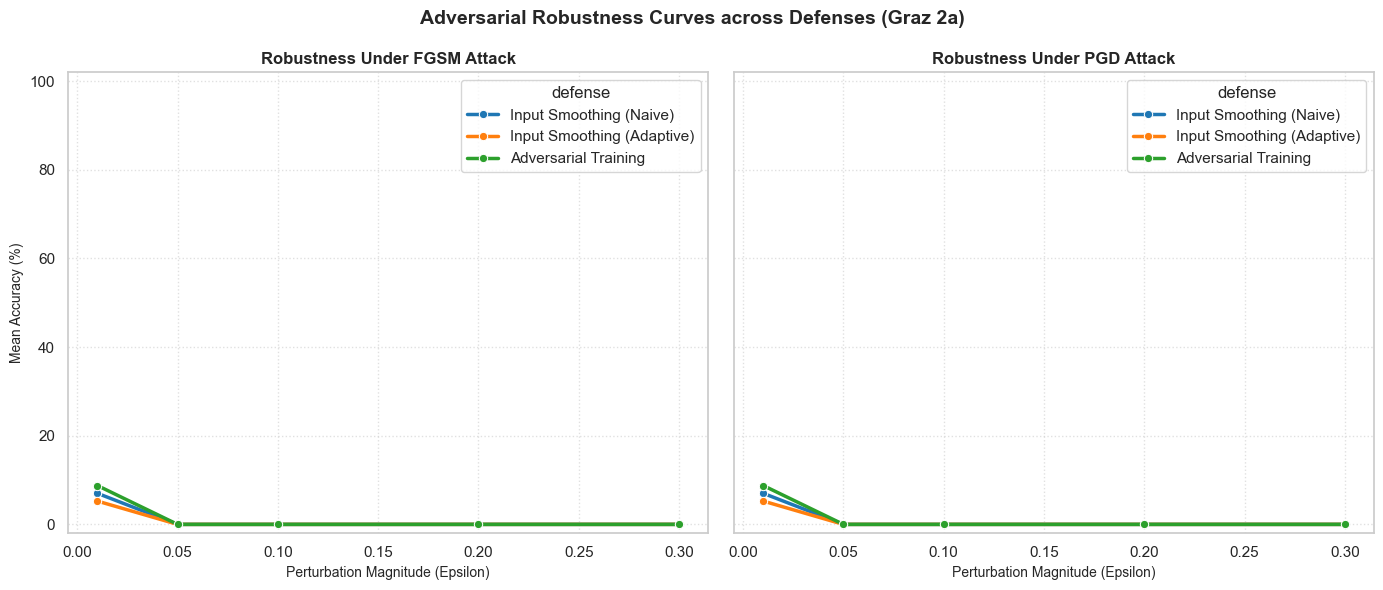

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

csv_path = '../results/tables/experiment_results.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} evaluation rows from {csv_path}.")
    
    # Format clean baseline entry (None attack, epsilon 0) so it replicates under defense options for plotting
    clean_rows = df[df['attack'] == 'None'].copy()
    
    # Replicate clean baseline across defenses for smooth curves starting at epsilon 0
    replicated_clean = []
    for def_name in ['None', 'Input Smoothing (Naive)', 'Input Smoothing (Adaptive)', 'Adversarial Training']:
        temp = clean_rows.copy()
        temp['defense'] = def_name
        replicated_clean.append(temp)
        
    df_filtered = df[df['attack'] != 'None'].copy()
    df_plot = pd.concat([df_filtered] + replicated_clean, ignore_index=True)
    
    # Setup styling
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Palette mapping for defenses
    palette = {
        'None': '#7f7f7f',                     # Muted gray
        'Input Smoothing (Naive)': '#1f77b4',    # Clean blue
        'Input Smoothing (Adaptive)': '#ff7f0e', # Alert orange
        'Adversarial Training': '#2ca02c'        # Robust green
    }
    
    # 1. FGSM Plot
    df_fgsm = df_plot[df_plot['attack'].isin(['FGSM', 'None'])]
    sns.lineplot(
        data=df_fgsm, x='epsilon', y='accuracy', hue='defense', 
        palette=palette, marker='o', linewidth=2.5, ax=axes[0]
    )
    axes[0].set_title('Robustness Under FGSM Attack', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Perturbation Magnitude (Epsilon)', fontsize=10)
    axes[0].set_ylabel('Mean Accuracy (%)', fontsize=10)
    axes[0].set_ylim(-2, 102)
    axes[0].grid(True, linestyle=':', alpha=0.6)
    
    # 2. PGD Plot
    df_pgd = df_plot[df_plot['attack'].isin(['PGD', 'None'])]
    sns.lineplot(
        data=df_pgd, x='epsilon', y='accuracy', hue='defense', 
        palette=palette, marker='o', linewidth=2.5, ax=axes[1]
    )
    axes[1].set_title('Robustness Under PGD Attack', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Perturbation Magnitude (Epsilon)', fontsize=10)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.suptitle('Adversarial Robustness Curves across Defenses (Graz 2a)', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    # Save figure
    os.makedirs('../results/figures', exist_ok=True)
    fig_path = '../results/figures/robustness_benchmark_curves.png'
    plt.savefig(fig_path, dpi=300)
    print(f"Robustness curve visualization saved to {fig_path}.")
    plt.show()
else:
    print("Results CSV not found. Please run experiments/run_experiment.py first.")